# Credit Risk: Predicting 90-Day Delinquency
Aditya Gujral · Python analytics portfolio · 100% synthetic data

## tl;dr
Logistic Regression was selected using validation ROC-AUC. On the untouched test cohort its ROC-AUC is **0.721**, versus **0.712** for Random Forest. The figures below show discrimination and the review-threshold tradeoff. No real-world predictive performance is claimed.

## Context & Methods
Predict whether a fictional account with starting DPD below 90 transitions to 90+ DPD within 90 days. This is a delinquency proxy, not legal default.

### Key Assumptions
One snapshot per customer. Features are generated as snapshot attributes; the future outcome is a stochastic simulation using those attributes plus unobserved noise. Training outcomes must mature before validation begins, and validation outcomes before test begins. The intervening embargo rows are intentionally excluded. Training-only imputation/scaling prevents preprocessing leakage. Select the model and threshold on validation only. No parameters are tuned to test results.

Sources: [data generator](generate_data.py), [pipeline](model.py), [scikit-learn leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
from model import run, ROOT
df, comparison, summary = run()

              model  roc_auc  average_precision  precision   recall  threshold
           Baseline 0.500000           0.518593   0.518593 1.000000        0.5
Logistic Regression 0.720586           0.728646   0.686508 0.670543        0.5
      Random Forest 0.712228           0.713193   0.674227 0.633721        0.5


## Data
6,000 historical account snapshots in 2025; 500 separate unlabeled scoring accounts dated June 30, 2026. This dataset is independent of the SQL example; it supplies the dated outcomes required for prediction.

In [2]:
display(df.head(5))
display(pd.DataFrame(summary['splits']).T)
print('Embargo rows excluded:', summary['excluded_embargo_rows'])
print('Missing income values:', df.monthly_income.isna().sum())

Embargo rows excluded: 3067
Missing income values: 153


,account_id,customer_id,snapshot_date,days_past_due,credit_score,monthly_income,balance,utilization,missed_payments_6m,portfolio,outcome_end_date,future_90dpd
0,1,1,2025-09-16,55,455,2788.76,10009.35,0.6300,1,Credit Card,2025-12-15,1
1,2,2,2025-07-11,74,730,5525.81,1887.16,0.9384,1,Personal Loan,2025-10-09,0
2,3,3,2025-06-05,57,682,NaN,10517.49,0.3499,1,Medical,2025-09-03,0
3,4,4,2025-01-31,53,595,2117.35,19420.91,0.3639,2,Auto,2025-05-01,1
4,5,5,2025-04-24,42,593,3907.44,5327.20,0.3822,1,Medical,2025-07-23,0


,rows,start,end,outcome_end,prevalence
train,1430,2025-01-01,2025-03-31,2025-06-29,0.514685
validation,508,2025-07-01,2025-07-31,2025-10-29,0.503937
test,995,2025-11-01,2025-12-31,2026-03-31,0.518593


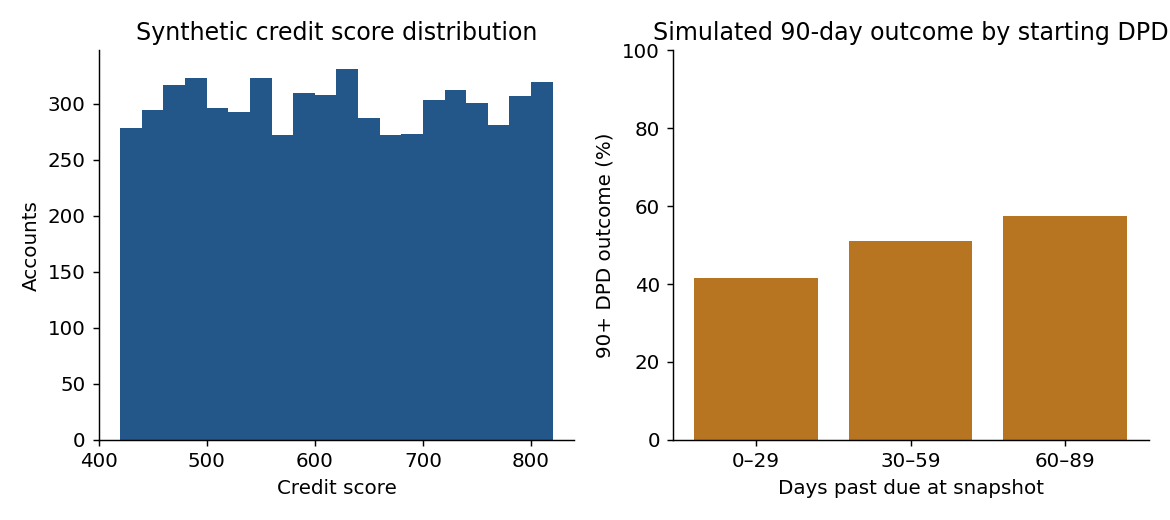

In [3]:
display(Image(filename=str(ROOT/'figures/data_exploration.png')))

Higher starting delinquency is associated with more simulated 90+ DPD events. This relationship partly reflects the generator design, not a discovery about actual customers.

## Results
### Model comparison
Both models use the same fixed 0.50 threshold below. ROC-AUC and average precision assess ranking without selecting a threshold. The prior-only baseline predicts the training event rate.

,model,roc_auc,average_precision,precision,recall,f1,brier,threshold
0,Baseline,0.500,0.519,0.519,1.000,0.683,0.250,0.5
1,Logistic Regression,0.721,0.729,0.687,0.671,0.678,0.213,0.5
2,Random Forest,0.712,0.713,0.674,0.634,0.653,0.217,0.5


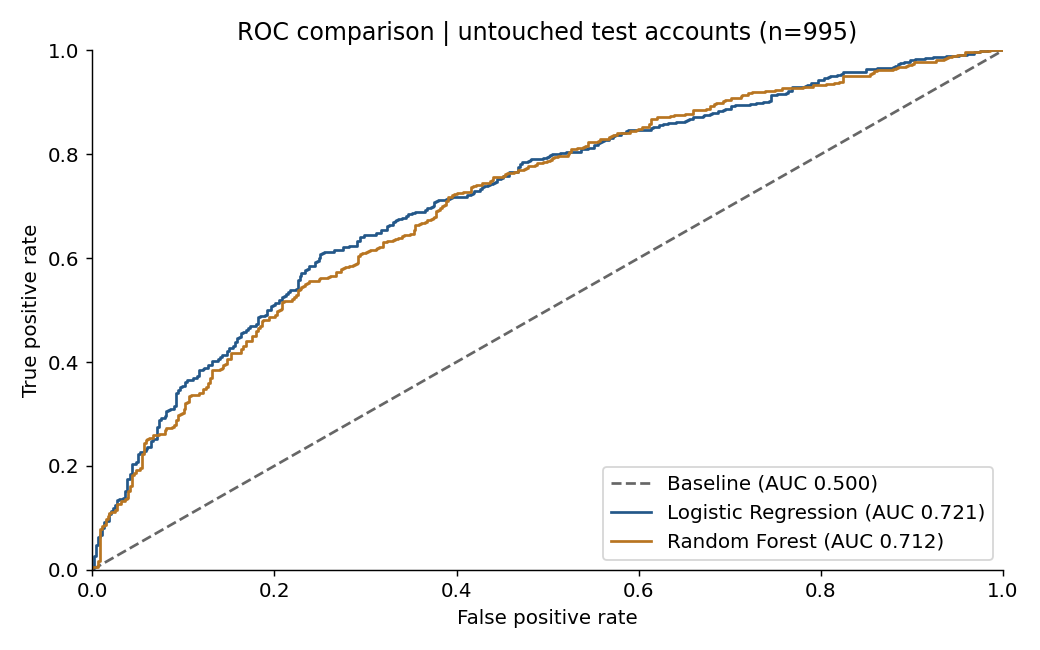

In [4]:
display(comparison[['model','roc_auc','average_precision','precision','recall','f1','brier','threshold']].round(3))
display(Image(filename=str(ROOT/'figures/roc_comparison.png')))

Logistic Regression ranks the synthetic test outcomes better than the prior-only baseline. The small difference versus Random Forest is descriptive; no significance claim is made.

### Operational threshold
The selected threshold maximizes validation F2 on a fixed grid, emphasizing recall. F2 is a demonstration objective; actual review capacity and costs would determine a production threshold.

,model,roc_auc,average_precision,precision,recall,f1,brier,threshold,tn,fp,fn,tp
0,Logistic Regression,0.721,0.729,0.563,0.93,0.702,0.213,0.26,107,372,36,480


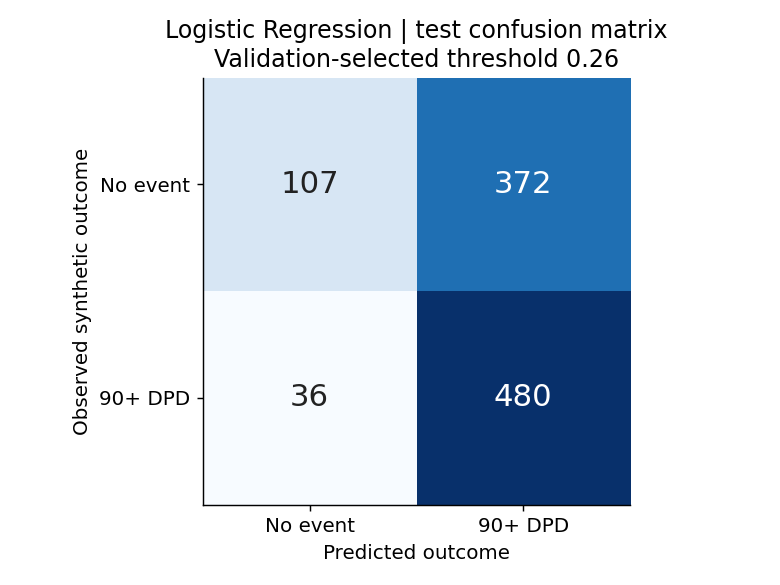

In [5]:
display(pd.read_csv(ROOT/'outputs/operating_point_metrics.csv').round(3))
display(Image(filename=str(ROOT/'figures/confusion_matrix.png')))

### What the model uses
Permutation importance measures test AUC reduction when a feature is shuffled. Error bars show variability across eight repeats, not confidence intervals. This diagnostic is not used for model selection and is not causal.

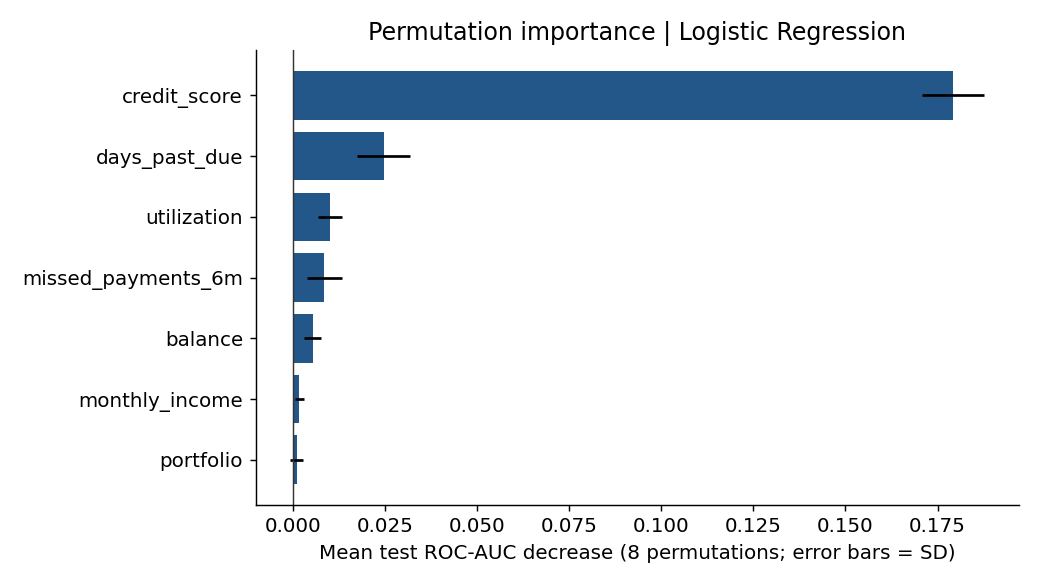

In [6]:
display(Image(filename=str(ROOT/'figures/feature_importance.png')))

### Separate scoring accounts
Scores are produced by the evaluated fitted model, with no hidden refit. These unlabeled scores are not included in test metrics.

In [7]:
scores = pd.read_csv(ROOT/'outputs/risk_scores.csv')
display(scores.head(10).round(3))
print('Unlabeled accounts scored:', len(scores))

Unlabeled accounts scored: 500


,account_id,snapshot_date,balance,risk_probability,review_flag
0,10210,2026-06-30,20917.28,0.909,True
1,10122,2026-06-30,4381.56,0.894,True
2,10368,2026-06-30,22345.87,0.874,True
3,10367,2026-06-30,21895.80,0.872,True
4,10019,2026-06-30,11762.06,0.869,True
5,10144,2026-06-30,14485.59,0.865,True
6,10027,2026-06-30,17190.01,0.860,True
7,10253,2026-06-30,24900.01,0.858,True
8,10083,2026-06-30,2459.53,0.854,True
9,10412,2026-06-30,14876.65,0.853,True


## Takeaways
The workflow demonstrates temporal separation, mature outcomes, leakage-safe preprocessing, model selection, threshold selection and account scoring. Use it to explain ranking versus decision thresholds in an interview.

Synthetic results do not establish production fitness. Real use needs observed delinquency histories, customer-group handling for repeated accounts, calibration, temporal robustness, fairness review and operational cost validation. Predicted scores here are illustrative and not calibrated financial probabilities.

Reproduce: `python model.py`; execute notebook: `python create_notebook.py`. Outputs are overwritten only in this project folder.